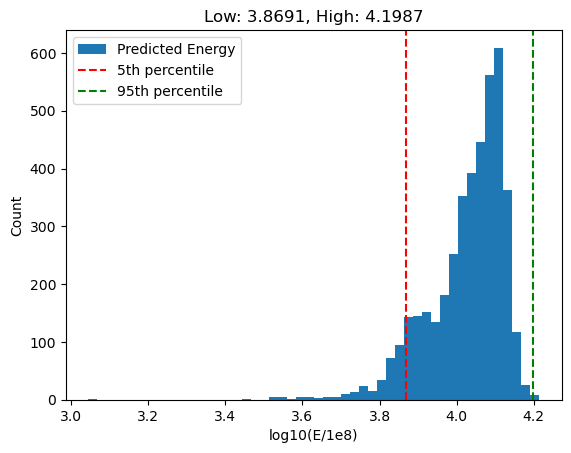

In [6]:
import numpy as np
import pandas as pd
import xgboost as xgb
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

class EnergyReconstructor:
    def __init__(self, model_path=None, linear_params_path=None):
        self.params = {
            'n_estimators': 1000,
            'learning_rate': 0.03,
            'max_depth': 8,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'random_state': 42
        }
        self.model = xgb.XGBRegressor(**self.params)
        self.model._estimator_type = "regressor"
        self.linear_model = LinearRegression()
        
        if model_path:
            self.model.load_model(model_path)
        if linear_params_path:
            with open(linear_params_path, 'r') as f:
                p = json.load(f)
            self.linear_model.coef_     = np.array(p['coef'])
            self.linear_model.intercept_ = p['intercept']

    def load_and_preprocess(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        
        cols_to_numeric = ['NuW3', 'rec_theta', 'dr', 'trueE']
        for col in cols_to_numeric:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df[df['NuW3'] > 0].copy()
        df['log_NuW3'] = np.log10(df['NuW3'])
        
        threshold = 3.16e9
        df_low  = df[df['trueE'] <  threshold].sample(frac=0.2, random_state=42)
        df_high = df[df['trueE'] >= threshold]
        df_balanced = pd.concat([df_low, df_high], ignore_index=True)
        
        mask = (df_balanced['dr'] > 0) & \
               (df_balanced['rec_theta'] > 0) & \
               (df_balanced['rec_theta'] <= np.deg2rad(70))
        clean_df = df_balanced[mask].copy()
        
        X = clean_df[['log_NuW3', 'rec_theta']].values
        y = np.log10(clean_df['trueE'] / 1e8)
        
        return X, y, clean_df['trueE']

    def train(self, X, y,
              model_save_path   = "/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json",
              linear_save_path  = "/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json"):
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=99)
        
        # ── Step 1: 线性模型拟合全局趋势 ──────────────────────────
        print("Fitting linear baseline model...")
        self.linear_model.fit(X_train, y_train)
        
        y_linear_train = self.linear_model.predict(X_train)
        y_linear_test  = self.linear_model.predict(X_test)
        
        print(f"  Linear model coef  : log_NuW3={self.linear_model.coef_[0]:.6f}, "
              f"rec_theta={self.linear_model.coef_[1]:.6f}")
        print(f"  Linear model intercept: {self.linear_model.intercept_:.6f}")
        
        # ── Step 2: XGBoost 仅拟合残差 ────────────────────────────
        y_residual_train = y_train - y_linear_train
        
        print("Training XGBoost residual model...")
        self.model.fit(X_train, y_residual_train)
        
        # ── Step 3: 组合预测与评估 ────────────────────────────────
        y_residual_pred = self.model.predict(X_test)
        y_pred = y_linear_test + y_residual_pred        # ← 最终预测
        
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)
        
        # 与纯线性对比
        mae_lin = mean_absolute_error(y_test, y_linear_test)
        r2_lin  = r2_score(y_test, y_linear_test)
        
        print(f"\n[Pure Linear]   MAE: {mae_lin:.4f},  R²: {r2_lin:.4f}")
        print(f"[Linear + XGB]  MAE: {mae:.4f},  R²: {r2:.4f}  ← final model")
        
        # ── Step 4: 保存 ──────────────────────────────────────────
        self.model.save_model(model_save_path)
        
        linear_params = {
            "coef":      self.linear_model.coef_.tolist(),   # [coef_log_NuW3, coef_rec_theta]
            "intercept": float(self.linear_model.intercept_),
            "feature_order": ["log_NuW3", "rec_theta"]       # 备忘顺序，C++对照
        }
        with open(linear_save_path, 'w') as f:
            json.dump(linear_params, f, indent=2)
        
        print(f"\nXGBoost model  saved → {model_save_path}")
        print(f"Linear params  saved → {linear_save_path}")
        
        return X_test, y_test, y_pred

    def predict(self, X):
        """组合预测：线性外推 + XGBoost残差"""
        return self.linear_model.predict(X) + self.model.predict(X)


# --- 使用示例 ---
agent = EnergyReconstructor(model_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json", 
                          linear_params_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json")
X, y, trueE = agent.load_and_preprocess("/data/home/zzh/data/Dataset_Filted/Monopole/1e12/filted_1e12_650_70_5400_merged_dataset_fastcode.npz")
# print(X)
recE = agent.predict(X)

import matplotlib.pyplot as plt
low,high = np.percentile(recE, [8,99.9])
plt.hist(recE, bins=50, label='Predicted Energy')
plt.xlabel('log10(E/1e8)')
plt.ylabel('Count')
plt.axvline(low, color='r', linestyle='--', label='5th percentile')
plt.axvline(high, color='g', linestyle='--', label='95th percentile')
plt.title(f'Low: {low:.4f}, High: {high:.4f}')
plt.legend()
plt.show()


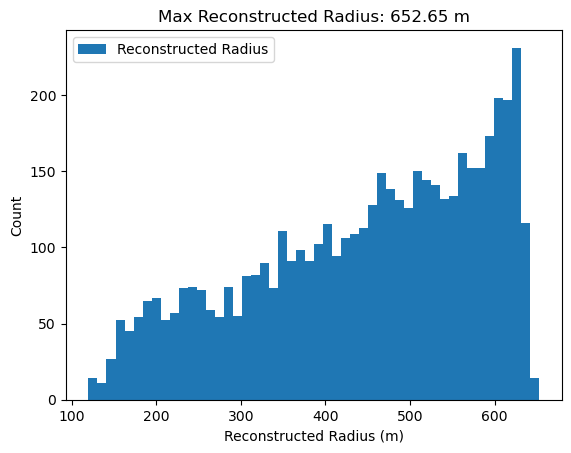

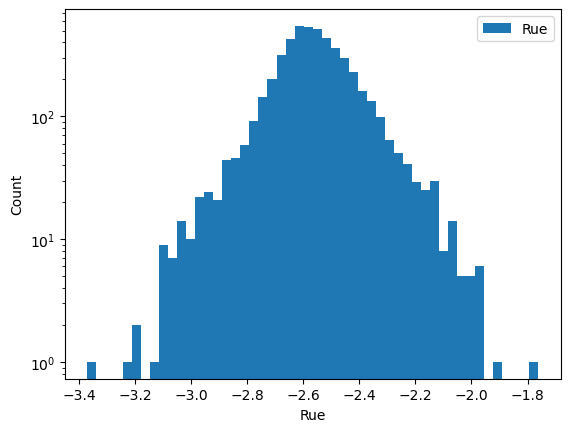

In [8]:
data = np.load("/data/home/zzh/data/Dataset_Filted/Monopole/1e12/filted_1e12_650_70_5400_merged_dataset_fastcode.npz", allow_pickle=True)
df = pd.DataFrame(data['params'], columns=data['param_names'])
df['rec_x'] = pd.to_numeric(df['rec_x'], errors='coerce'); df['rec_y'] = pd.to_numeric(df['rec_y'], errors='coerce'); df['rec_r'] = np.sqrt(df['rec_x']**2 + df['rec_y']**2)
plt.hist(df['rec_r'], bins=50, label='Reconstructed Radius')
plt.xlabel('Reconstructed Radius (m)')
plt.ylabel('Count')
plt.legend()
plt.title(f'Max Reconstructed Radius: {df["rec_r"].max():.2f} m')
plt.show()

plt.hist(df['R_ue'], bins=50, label='Rue', )
plt.xlabel('Rue')
plt.ylabel('Count')
plt.yscale('log')
plt.legend()
plt.show()


43


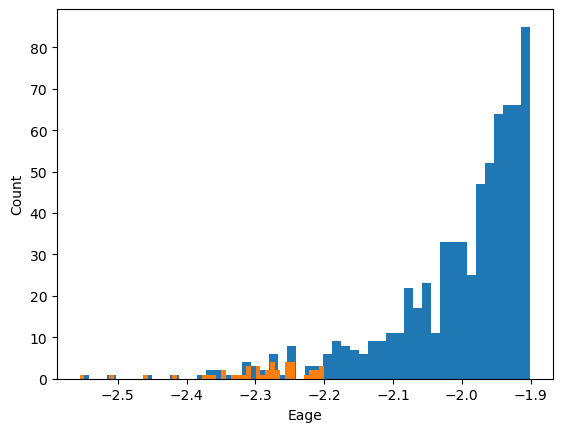

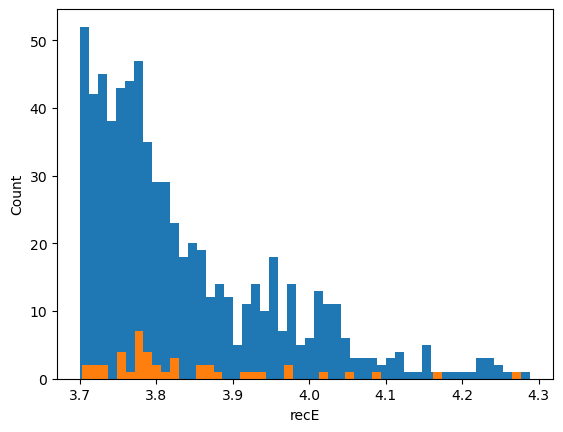

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data=np.load("/data/home/zzh/data/Dataset_Filted/Experiment/1e12_V04/all_tmp_merged.npz", allow_pickle=True)
df = pd.DataFrame(data['params'], columns=data['param_names'])
len(df)
df_tail = df[df['R_ue']<-2.2]
print(len(df_tail))
plt.hist(df['R_ue'], bins=50, label='Rue', )
plt.hist(df_tail['R_ue'], bins=50, label='Rue',)
# plt.hist(df_tail['Eage'], )
plt.xlabel('Eage')
plt.ylabel('Count')
plt.show()
plt.hist(df['recE'], bins=50, label='recE',)
plt.hist(df_tail['recE'], bins=50, label='recE',)
plt.xlabel('recE')
plt.ylabel('Count')
plt.show()